<a href="https://colab.research.google.com/github/arturbernardo/word_vectors/blob/main/LLM_HOW_TO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Base de dados vetorial:

O planeta terra é precioso

Os astronautas viram a terra de longe

Na terra existe vida

terra: [

  é: 10%

  de: 14%

  existe: 1%

  a: 9%

  ...
  
]

preposições e artigos viram um problema

é: [

  feio: 0.01%

  bonito: 0.01%

  grande: 0.01%

  pequeno: 0.01%

  ... ++ 350 mil palavras
  
]



terra: [

  planeta: 5%

  astronautas: 2%

  vida: 4%

  ...

]

O carro ficou sujo de terra (...)

[planeta, astronauta, vida, aliens]

na verdade a palavra desejada era "no rali"

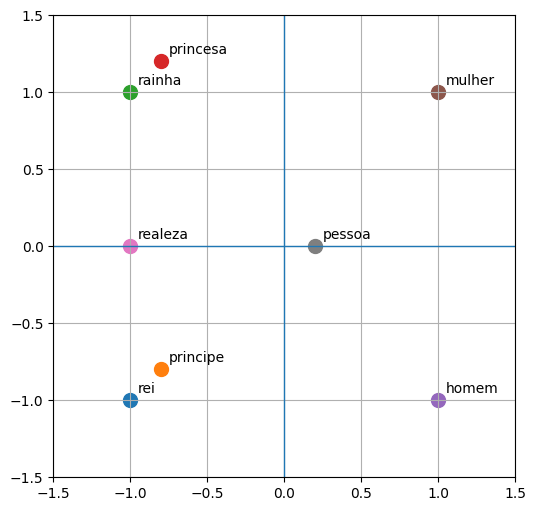

In [73]:
import matplotlib.pyplot as plt

palavras = {
    "rei":     [-1,-1],
    "rainha":  [-1, 1],
    "homem":   [1,-1],
    "mulher":  [1, 1],
}


palavras = {
    "rei":     [-1,-1],
    "rainha":  [-1, 1],
    "princesa":  [-0.8, 1.2],
    "homem":   [1,-1],
    "mulher":  [1, 1],
}

palavras = {
    "rei":     [-1,-1],
    "principe": [-0.8,-0.8],
    "rainha":  [-1, 1],
    "princesa": [-0.8, 1.2],
    "homem":   [1,-1],
    "mulher":  [1, 1],
    "realeza":  [-1, 0],
    "pessoa":  [0.2, 0],
}

plt.figure(figsize=(6,6))

for palavra, (x, y) in palavras.items():
    plt.scatter(x, y, s=100)
    plt.text(x + 0.05, y + 0.05, palavra)

# eixos cartesianos
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)


plt.grid(True)
plt.gca().set_aspect("equal")

plt.show()

In [59]:
vectors_default = {
    w: np.random.randn(2)
    for w in words
}

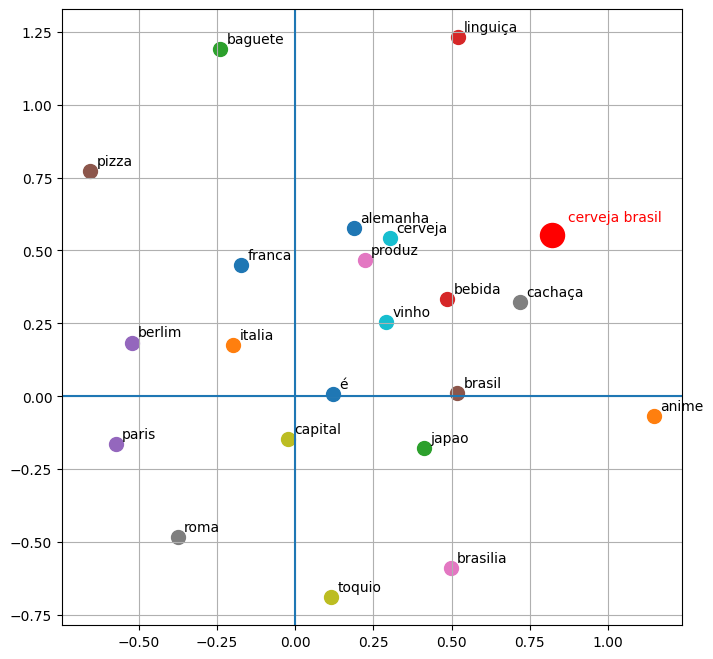

In [70]:
import numpy as np
import matplotlib.pyplot as plt

sentences = [

    # países
    ["brasil", "capital", "é", "brasilia"],
    ["franca", "capital", "é", "paris"],
    ["italia", "capital", "é", "roma"],
    ["alemanha", "capital", "é", "berlim"],
    ["japao", "capital", "é", "toquio"],


    ["japao", "produz", "anime"],
    ["japao", "produz", "vinho"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "linguiça"],
    ["italia", "produz", "vinho"],
    ["italia", "produz", "pizza"],
    ["franca", "produz", "baguete"],
    ["franca", "produz", "vinho"],
    ["brasil", "produz", "cachaça"],
    ["brasil", "produz", "vinho"],

    ["cachaça", "é", "bebida"],
    ["cerveja", "é", "bebida"],
    ["vinho", "é", "bebida"],

    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],
    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],
    ["cachaça", "bebida"],
    ["cerveja", "bebida"],
    ["vinho", "bebida"],


    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],
    ["alemanha", "produz", "cerveja"],


    # ["cachaça", "alemanha"],


]

# palavras únicas
words = sorted(set(w for s in sentences for w in s))

# posição aleatória 2D inicial
vectors = vectors_default.copy();

learning_rate = 0.01
repulsion = 0.001

for epoch in range(1000):

    # atração: palavras que aparecem juntas
    for sentence in sentences:
        for i in range(len(sentence)):
            for j in range(i + 1, len(sentence)):

                w1 = sentence[i]
                w2 = sentence[j]

                v1 = vectors[w1]
                v2 = vectors[w2]

                delta = v2 - v1

                vectors[w1] += learning_rate * delta
                vectors[w2] -= learning_rate * delta

    # repulsão: evita tudo colapsar
    for w1 in words:
        for w2 in words:
            if w1 == w2:
                continue

            v1 = vectors[w1]
            v2 = vectors[w2]

            delta = v1 - v2
            dist = np.linalg.norm(delta) + 1e-6

            vectors[w1] += repulsion * delta / (dist ** 2)

# desenho
plt.figure(figsize=(8, 8))

for word, vec in vectors.items():
    x, y = vec

    plt.scatter(x, y, s=100)
    plt.text(x + 0.02, y + 0.02, word)


#
resultado = (
    vectors["cerveja"]
    + vectors["brasil"]
)

plt.scatter(resultado[0], resultado[1], s=300, color="red")

plt.text(
    resultado[0] + 0.05,
    resultado[1] + 0.05,
    "cerveja brasil",
    color="red"
)
#

plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.show()

In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

corpus = [
    "empresa lucro",
    "ong doacao",
    "empresa doacao",
    "gato telhado"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

sim = cosine_similarity(X)

print(sim)

[[1.  0.  0.5 0. ]
 [0.  1.  0.5 0. ]
 [0.5 0.5 1.  0. ]
 [0.  0.  0.  1. ]]


1.0 = mesma direção
0.5 = direção parcialmente parecida
0.0 = direções sem nenhuma palavra em comum

cos(ângulo) = 0.5 = 60∘


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact


def circulo(angulo):
    theta = np.radians(angulo)

    x = np.cos(theta)
    y = np.sin(theta)

    fig, ax = plt.subplots(figsize=(6,6))

    t = np.linspace(0, 2*np.pi, 500)
    ax.plot(np.cos(t), np.sin(t))

    ax.axhline(0)
    ax.axvline(0)

    ax.plot([0, x], [0, y], linewidth=3)

    ax.plot([x, x], [0, y], linestyle='--')

    ax.scatter([x], [y], s=100)

    ax.text(0.05, 1.1,
            f"ângulo = {angulo}°\n"
            f"cos = {x:.3f}\n"
            f"sin = {y:.3f}",
            fontsize=12)

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

    ax.set_aspect('equal')

    plt.show()


interact(circulo, angulo=(1, 360, 1))

interactive(children=(IntSlider(value=180, description='angulo', max=360, min=1), Output()), _dom_classes=('wi…

<function __main__.circulo(angulo)>

In [25]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = ["o", "rei", "fujiu", "do", "reino"]
embeddings = model.encode(sentences)

from sklearn.metrics.pairwise import cosine_similarity
print(cosine_similarity(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[1.0000001  0.29204395 0.27317104 0.40759495 0.36158746]
 [0.29204395 1.         0.2494547  0.21778983 0.47687414]
 [0.27317104 0.2494547  1.0000002  0.20646888 0.31079614]
 [0.40759495 0.21778983 0.20646888 1.         0.15925479]
 [0.36158746 0.47687414 0.31079614 0.15925479 1.        ]]


Vetores na LLM

Transformer